# The RoboAI UR5e Dataset and the Thesis Idea

This notebook explains, step by step and in simple words:

**Part A — the dataset:** what it is, what one recording looks like, what is measured, which tasks the robot does, and which problems we found in the data.

**Part B — the project (Option 1):** the problem, the idea, the aim, the research questions, the methods, how we test them, and the results so far.

| Part | Step | Question it answers |
|---|---|---|
| A | 1 | Where does the data come from? |
| A | 2 | How much data is there? |
| A | 3 | What does one recording look like? |
| A | 4 | What is measured at each moment? |
| A | 5 | Which tasks does the robot do? |
| A | 6 | How does the robot move? |
| A | 7 | Is the data clean? |
| A | 8 | What can this data be used for, and what not? |
| B | 9 | What problem does the project solve? |
| B | 10 | What is the idea? (with a small live demo) |
| B | 11 | What is the aim, and what are the research questions? |
| B | 12 | Which methods are compared? |
| B | 13 | How do we test them? |
| B | 14 | What are the results so far? |
| B | 15 | What are the limits, and what comes next? |

The full experiments are in **`option1_motion_anomaly_detection.ipynb`**; this notebook reads its saved results from the `results/` folder.

## Setup

In [1]:
import os, re, time
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATASET_PATH = r"C:\Users\Nahid\Test\dataset"                     # full dataset (only needed for camera images)
PROCESSED_PATH = r"C:\Users\Nahid\Test\processed\robot_motion.npz"  # small file with the robot numbers
RESULTS_DIR = r"C:\Users\Nahid\Test\results"                       # results saved by the Option 1 notebook

pd.set_option("display.precision", 3)
pd.set_option("display.max_colwidth", 70)
HAVE_IMAGES = os.path.exists(os.path.join(DATASET_PATH, "dataset_info.json"))
HAVE_RESULTS = os.path.exists(os.path.join(RESULTS_DIR, "summary_all_methods.csv"))
print(f"Full dataset available (for images): {HAVE_IMAGES}")
print(f"Option 1 results available:          {HAVE_RESULTS}")

Full dataset available (for images): True
Option 1 results available:          True


---
# Part A — The dataset

## Step 1 — Where does the data come from?

| | |
|---|---|
| **Name** | RoboAI UR5e Dataset (`robo_ai_u_r5e`, version 1.0.0) |
| **Made by** | Joonas Rouhiainen, RoboAI Research Center, Satakunta University of Applied Sciences (2025) |
| **Download** | <https://huggingface.co/datasets/Rouhis/RoboAI_UR5e> (about 24 GB) |
| **License** | CC BY 4.0 — free to use if you cite the authors |
| **Robot** | Universal Robots **UR5e**, a 6-joint robot arm with a gripper |
| **How it was made** | A person controlled the robot (teleoperation) to show it how to do table-top tasks |
| **Purpose (from the authors)** | "Real-world robotic demonstrations collected from UR5e for language-conditioned manipulation" |
| **Format** | RLDS / TensorFlow Datasets: a list of **recordings** (episodes), each a sequence of **time steps** |

Every time step stores a **camera image**, the **robot state**, a **command**, and the **task sentence** (for example *"stack the cups"*).

## Step 2 — How much data is there?

To keep things small and fast, the robot numbers (not the images) were extracted once into `processed/robot_motion.npz` (about 4 MB). If that file is missing, the next cell creates it from the full dataset.

Recordings:          443
Time steps in total: 57,742
Steps per recording: 82 to 349 (average 130)
Camera images:       57,742 images of 480 x 640 pixels (in the full dataset)


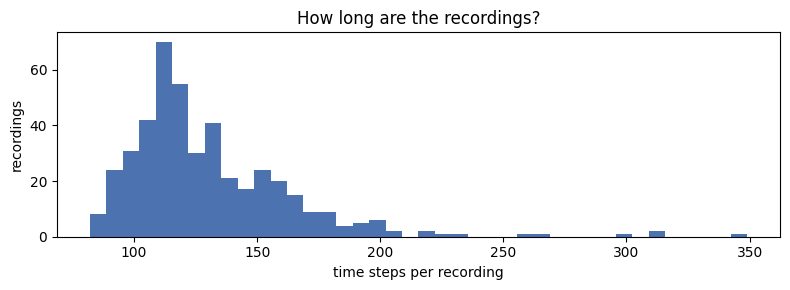

In [2]:
if not os.path.exists(PROCESSED_PATH):
    import tensorflow as tf
    tf.config.set_visible_devices([], "GPU")
    import tensorflow_datasets as tfds
    builder = tfds.builder_from_directory(DATASET_PATH)
    decoders = {"steps": {"observation": {"image": tfds.decode.SkipDecoding()}}}
    S, Acts, L, I, Fn = [], [], [], [], []
    for ep in builder.as_dataset(split="train", decoders=decoders):
        rows = [(s["observation"]["robot_state"].numpy(), s["action"].numpy(), s["language_instruction"].numpy())
                for s in ep["steps"]]
        S.append(np.stack([r[0] for r in rows])); Acts.append(np.stack([r[1] for r in rows])); L.append(len(rows))
        I.append(rows[-1][2].decode()); Fn.append(ep["episode_metadata"]["file_name"].numpy().decode())
    os.makedirs(os.path.dirname(PROCESSED_PATH), exist_ok=True)
    np.savez_compressed(PROCESSED_PATH, states=np.concatenate(S).astype(np.float32),
                        actions=np.concatenate(Acts).astype(np.float32), lengths=np.array(L),
                        instructions=np.array(I), file_names=np.array(Fn))

data = np.load(PROCESSED_PATH)
lengths = data["lengths"]
offsets = np.concatenate([[0], np.cumsum(lengths)])
states = [data["states"][offsets[i]:offsets[i + 1]] for i in range(len(lengths))]
commands = [data["actions"][offsets[i]:offsets[i + 1]] for i in range(len(lengths))]
instructions, file_names = data["instructions"], data["file_names"]

print(f"Recordings:          {len(lengths)}")
print(f"Time steps in total: {offsets[-1]:,}")
print(f"Steps per recording: {lengths.min()} to {lengths.max()} (average {lengths.mean():.0f})")
print(f"Camera images:       {offsets[-1]:,} images of 480 x 640 pixels (in the full dataset)")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(lengths, bins=40, color="#4c72b0")
ax.set_xlabel("time steps per recording"); ax.set_ylabel("recordings"); ax.set_title("How long are the recordings?")
plt.tight_layout(); plt.show()

**What this means:** 443 recordings of about 130 steps each, roughly 58,000 moments in total. That is small compared with big robot datasets, but plenty for learning how the robot normally moves.

## Step 3 — What does one recording look like?

Six camera frames from the first recording, from start to end. Below them: the hand position and the gripper over the same recording.

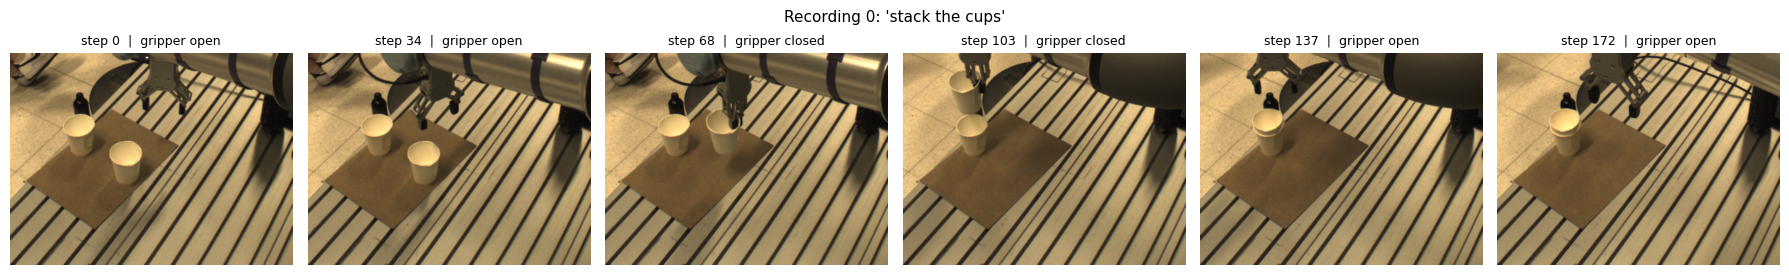

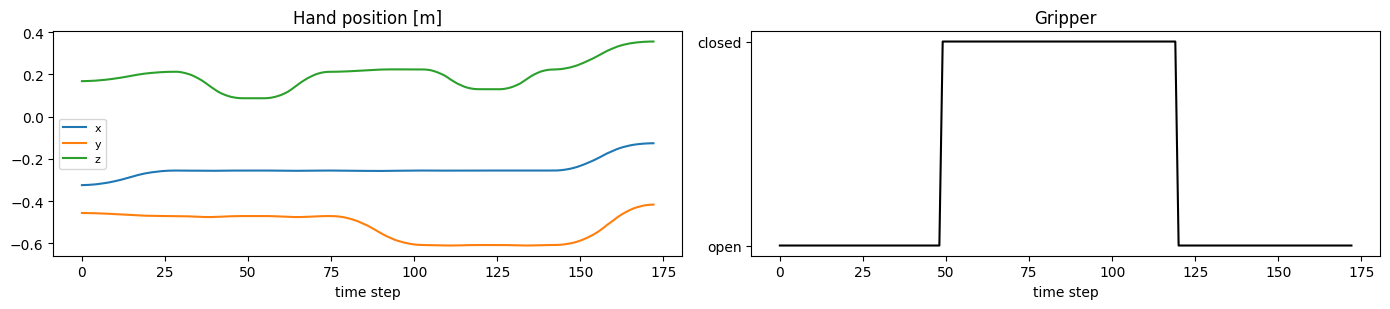

In [3]:
EP = 0
if HAVE_IMAGES:
    import tensorflow as tf
    tf.config.set_visible_devices([], "GPU")
    import tensorflow_datasets as tfds
    builder = tfds.builder_from_directory(DATASET_PATH)
    ep = next(iter(builder.as_dataset(split=f"train[{EP}:{EP + 1}]")))
    frames = [s["observation"]["image"] for s in tfds.as_numpy(ep["steps"])]
    picks = np.linspace(0, len(frames) - 1, 6).astype(int)
    fig, axes = plt.subplots(1, 6, figsize=(18, 2.8))
    for ax, t in zip(axes, picks):
        ax.imshow(frames[t]); ax.axis("off")
        ax.set_title(f"step {t}  |  gripper {'closed' if states[EP][t, 13] > 0.5 else 'open'}", fontsize=9)
    fig.suptitle(f"Recording {EP}: '{instructions[EP]}'", fontsize=11)
    plt.tight_layout(); plt.show()
else:
    print("Full dataset not found, so no camera images are shown. The robot numbers below still work.")

s = states[EP]
fig, axes = plt.subplots(1, 2, figsize=(14, 3.2))
for j, name in zip(range(6, 9), ["x", "y", "z"]):
    axes[0].plot(s[:, j], label=name)
axes[0].set_title("Hand position [m]"); axes[0].legend(fontsize=8)
axes[1].plot(s[:, 13], color="k"); axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(["open", "closed"])
axes[1].set_title("Gripper")
for ax in axes:
    ax.set_xlabel("time step")
plt.tight_layout(); plt.show()

**What this means:** one recording is one complete task: the arm moves to an object, closes the gripper, carries the object, releases it, and moves away.

## Step 4 — What is measured at each moment?

At every time step the dataset stores:

| Field | Size | What it is |
|---|---|---|
| `observation/image` | 480 × 640 × 3 | camera picture of the table |
| `observation/robot_state` | 15 numbers | where the robot is (table below) |
| `action` | 7 numbers | the "command" (see Step 7 for a surprise) |
| `language_instruction` | text | the task, e.g. *"stack the cups"* |
| `absolute_action_mask`, `action_normalization_mask` | 7 yes/no | tell learning software how to treat each action value |

The 15 robot-state numbers (meaning inferred from the data — to confirm with the dataset author):

In [4]:
STATE_INFO = [
    ("joint0 … joint5", "0–5", "angle of each of the 6 joints", "rad"),
    ("x, y, z", "6–8", "position of the robot hand", "m"),
    ("q0 … q3", "9–12", "orientation of the hand (a quaternion: 4 numbers for a 3-D rotation)", "—"),
    ("gripper", "13", "0 = open, 1 = closed", "—"),
    ("unused", "14", "always 0", "—"),
]
display(pd.DataFrame(STATE_INFO, columns=["name", "index", "meaning", "unit"]).set_index("name"))

first = pd.DataFrame({"value at step 0": states[EP][0]},
                     index=[f"joint{i}" for i in range(6)] + ["x", "y", "z", "q0", "q1", "q2", "q3", "gripper", "unused"])
print(f"Example — the 15 numbers at the first step of recording {EP}:")
display(first.T.round(3))

,index,meaning,unit
name,,,
joint0 … joint5,0–5,angle of each of the 6 joints,rad
"x, y, z",6–8,position of the robot hand,m
q0 … q3,9–12,orientation of the hand (a quaternion: 4 numbers for a 3-D rotation),—
gripper,13,"0 = open, 1 = closed",—
unused,14,always 0,—


Example — the 15 numbers at the first step of recording 0:


,joint0,joint1,joint2,joint3,joint4,joint5,x,y,z,q0,q1,q2,q3,gripper,unused
value at step 0,-1.947,-1.74,-1.732,-1.236,1.571,-0.699,-0.324,-0.456,0.168,0.987,0.16,-0.0,0.0,0.0,0.0


## Step 5 — Which tasks does the robot do?

The task sentences are written by people, so the same task is often worded differently (*"stack cups"*, *"stack the cups"*). We merge such variants by removing small words and punctuation.

Different sentences:           137
Different tasks after merging: 120
Top 2 tasks cover:             68% of all recordings
Tasks with only 1 recording:   101


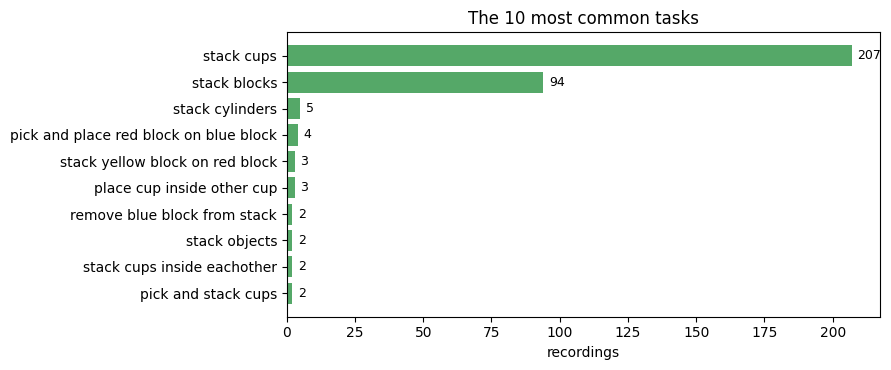

In [5]:
def simplify(sentence):
    s = re.sub(r"[^a-z ]", " ", sentence.lower())
    s = re.sub(r"\b(the|a|an)\b", " ", s)
    return re.sub(r"\s+", " ", s).strip()

tasks = [simplify(t) for t in instructions]
counts = Counter(tasks)
top = pd.Series(counts).sort_values(ascending=False)

print(f"Different sentences:           {len(set(instructions))}")
print(f"Different tasks after merging: {len(counts)}")
print(f"Top 2 tasks cover:             {top.iloc[:2].sum() / len(tasks):.0%} of all recordings")
print(f"Tasks with only 1 recording:   {(top == 1).sum()}")

fig, ax = plt.subplots(figsize=(9, 3.8))
t10 = top.head(10)[::-1]
ax.barh(t10.index, t10.values, color="#55a868")
for y, v in enumerate(t10.values):
    ax.text(v + 2, y, str(v), va="center", fontsize=9)
ax.set_xlabel("recordings"); ax.set_title("The 10 most common tasks")
plt.tight_layout(); plt.show()

**What this means:** the dataset is mostly about **stacking** (cups and blocks). Many other tasks appear only once. So it is **not** well suited for learning many different tasks from language, but it is well suited for learning what *normal* motion looks like, because the same kind of motion is repeated hundreds of times.

## Step 6 — How does the robot move?

Left: the path of the hand seen from above for 8 recordings (thick = gripper closed, i.e. carrying something). Right: how many times the gripper closes in each recording.

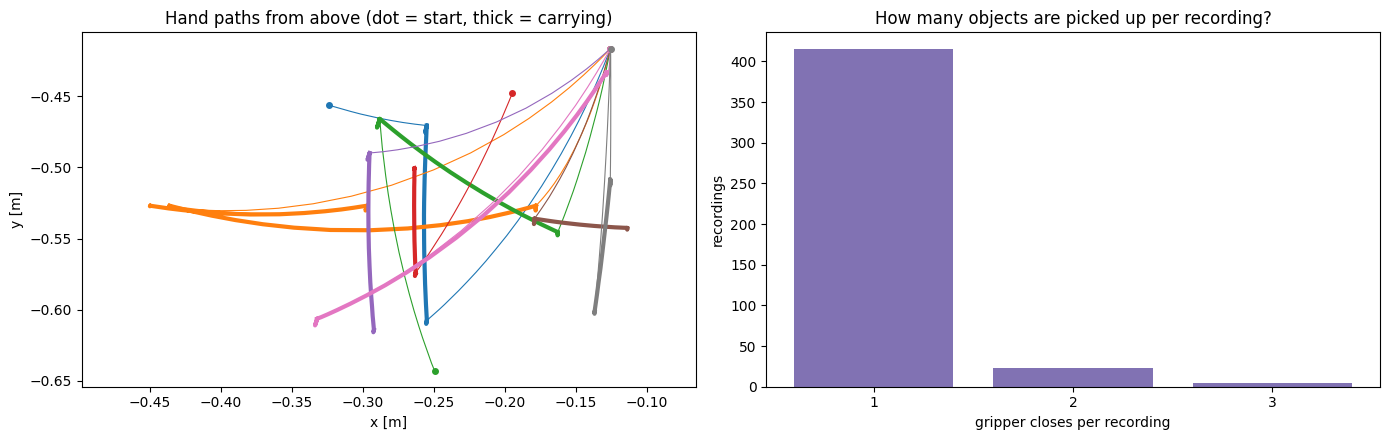

Typical hand movement per time step: 6.2 mm (fastest 1 %: > 26.2 mm)
Recordings with exactly one grasp:   94%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for i in range(8):
    s = states[i]
    axes[0].plot(s[:, 6], s[:, 7], lw=0.8, color=f"C{i}")
    closed = s[:, 13] > 0.5
    axes[0].plot(np.where(closed, s[:, 6], np.nan), np.where(closed, s[:, 7], np.nan), lw=3, color=f"C{i}")
    axes[0].plot(s[0, 6], s[0, 7], "o", color=f"C{i}", ms=4)
axes[0].set_xlabel("x [m]"); axes[0].set_ylabel("y [m]"); axes[0].set_aspect("equal", adjustable="datalim")
axes[0].set_title("Hand paths from above (dot = start, thick = carrying)")

grasps = [int(np.sum(np.diff((s[:, 13] > 0.5).astype(int)) == 1) + (s[0, 13] > 0.5)) for s in states]
g = pd.Series(grasps).value_counts().sort_index()
axes[1].bar(g.index.astype(str), g.values, color="#8172b3")
axes[1].set_xlabel("gripper closes per recording"); axes[1].set_ylabel("recordings")
axes[1].set_title("How many objects are picked up per recording?")
plt.tight_layout(); plt.show()

step_mm = np.concatenate([np.linalg.norm(np.diff(s[:, 6:9], axis=0), axis=1) for s in states]) * 1000
print(f"Typical hand movement per time step: {np.median(step_mm):.1f} mm (fastest 1 %: > {np.percentile(step_mm, 99):.1f} mm)")
print(f"Recordings with exactly one grasp:   {np.mean(np.array(grasps) == 1):.0%}")

**What this means:** the robot follows similar, smooth paths again and again, and almost every recording has exactly **one pick-and-place**. Smooth, repeated motion is exactly what a model can learn, which is the basis of the project in Part B.

## Step 7 — Is the data clean?

Four checks. Each one matters for the project.

In [7]:
allS = np.concatenate(states)

# 1) quaternion sign flips
qn = np.linalg.norm(allS[:, 9:13], axis=1)
flips = sum(int((np.einsum("ij,ij->i", s[1:, 9:13], s[:-1, 9:13]) < 0).sum()) for s in states)

# 2) are the commands just the recorded movement?
move = np.concatenate([np.diff(s[:, 6:9], axis=0) for s in states])
cmd = np.concatenate([c[1:, :3] for c in commands])
cmd_is_move = np.mean(np.all(np.abs(cmd - move) < 1e-6, axis=1))
grip_is_state = np.mean(np.concatenate([c[:, 6] for c in commands]) == allS[:, 13])

# 3) unused value
unused_const = np.all(allS[:, 14] == 0)

checks = pd.DataFrame([
    ("Orientation stored as a proper quaternion", f"length always {qn.min():.4f}–{qn.max():.4f}", "OK"),
    ("Orientation sign flips (q and −q mean the same)", f"{flips} sudden flips", "FIX: flip back, or they look like fake failures"),
    ("Hand 'command' = hand movement since last step", f"{cmd_is_move:.1%} of steps", "IMPORTANT: commands are not independent (see below)"),
    ("Gripper 'command' = current gripper state", f"{grip_is_state:.1%} of steps", "same as above"),
    ("Value 14 is always 0", str(bool(unused_const)), "ignore it"),
    ("Success / failure labels", "none in the dataset", "failures must be created for testing (Step 13)"),
    ("Recordings of real failures", "none known", "we look for unusual recordings ourselves"),
], columns=["check", "finding", "what it means"])
display(checks.set_index("check"))

,finding,what it means
check,,
Orientation stored as a proper quaternion,length always 1.0000–1.0000,OK
Orientation sign flips (q and −q mean the same),359 sudden flips,"FIX: flip back, or they look like fake failures"
Hand 'command' = hand movement since last step,100.0% of steps,IMPORTANT: commands are not independent (see below)
Gripper 'command' = current gripper state,100.0% of steps,same as above
Value 14 is always 0,True,ignore it
Success / failure labels,none in the dataset,failures must be created for testing (Step 13)
Recordings of real failures,none known,we look for unusual recordings ourselves


**The most important finding:** the dataset calls one field the robot's **action** (command), but it is simply the **movement the robot already made**, written down a second time. It is not an independent instruction from the controller. This matters for research question 3 (Step 11).

## Step 8 — What can this data be used for, and what not?

| The data **has** | So it **can** support | The data **does not have** | So it **cannot** support (well) |
|---|---|---|---|
| 443 recordings of smooth, repeated motion | learning what *normal* motion looks like | labelled failures | directly training a failure classifier |
| exact robot positions over time | predicting future motion | success / failure labels | success prediction without extra labelling |
| one camera | video-based studies | several cameras, depth, force sensor | multi-sensor studies |
| language sentences | task recognition | many different tasks | language-conditioned multi-task learning |
| — | — | independent controller commands | testing whether commands help (see Step 11) |

**Conclusion of Part A:** the dataset is a good fit for a project that **learns normal robot motion and detects when motion becomes abnormal** — that is Option 1.

---
# Part B — The project (Option 1)

## Step 9 — What problem does the project solve?

Robot arms sometimes fail: they **bump** into something, **get stuck**, slowly **drift** away from their path, or a **sensor** gives wrong readings.

- **Fast** failures are easy to notice.
- **Slow** failures (freezing, drifting) are easy to miss until something breaks.
- To learn to recognise failures, you would normally need many *examples of failures*, but robots are almost always recorded while working **normally**.

> **The problem:** how can we detect robot failures when we only have recordings of normal work?

## Step 10 — What is the idea?

Teach a model what **normal** motion looks like by letting it **predict** the robot's next moves. When the robot suddenly moves in a way the model did not expect, something is probably wrong.

```
 last 10 moments ──► model predicts the next moments ──► compare with what really happens
                                                              │
                                   small difference  →  normal
                                   large difference  →  ALARM
```

**Small live demo.** Below, a real recording gets an artificial **freeze** (the robot "gets stuck" for 15 steps). The simplest possible predictor, *"the robot keeps its speed"*, is used. Watch the difference between prediction and reality jump when the freeze starts and ends.

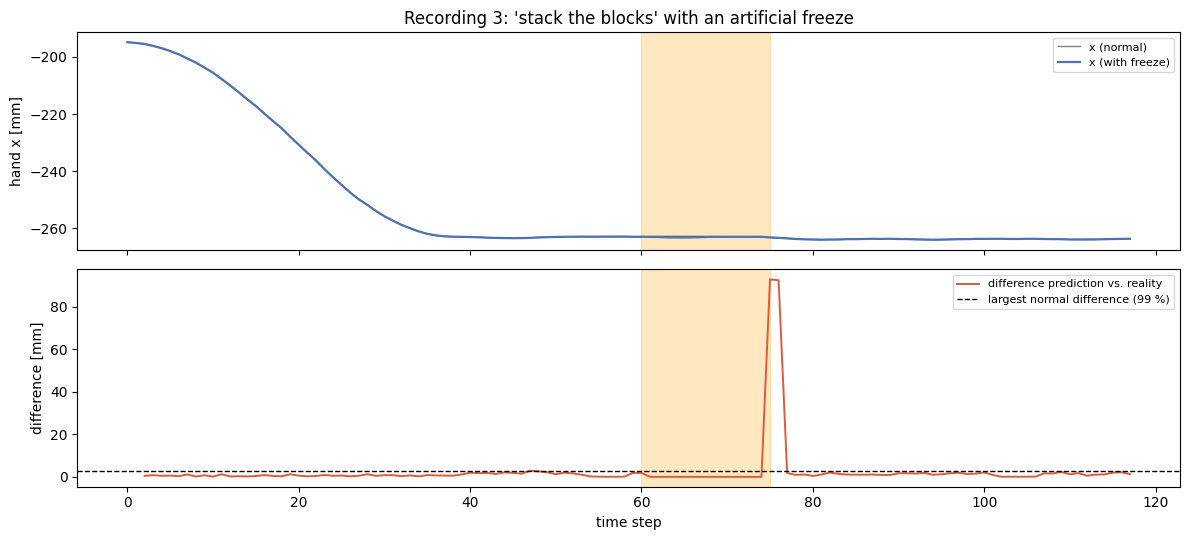

During the freeze the difference reaches 93.0 mm; in normal motion it stays below 2.7 mm in 99 % of steps.


In [8]:
DEMO, T0, LEN = 3, 60, 15
s = states[DEMO][:, 6:9].copy() * 1000             # hand position in mm
damaged = s.copy()
damaged[T0:T0 + LEN] = damaged[T0 - 1]              # the robot "gets stuck"

pred = np.full_like(damaged, np.nan)
pred[2:] = damaged[1:-1] + (damaged[1:-1] - damaged[:-2])     # "keeps its speed"
gap = np.linalg.norm(damaged - pred, axis=1)
normal_gap = np.nanpercentile(np.linalg.norm(s[2:] - (s[1:-1] + (s[1:-1] - s[:-2])), axis=1), 99)

fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)
axes[0].plot(s[:, 0], color="grey", lw=1, label="x (normal)")
axes[0].plot(damaged[:, 0], color="#4c72b0", lw=1.6, label="x (with freeze)")
axes[0].set_ylabel("hand x [mm]"); axes[0].legend(fontsize=8)
axes[0].set_title(f"Recording {DEMO}: '{instructions[DEMO]}' with an artificial freeze")
axes[1].plot(gap, color="#dd5a3a", lw=1.4, label="difference prediction vs. reality")
axes[1].axhline(normal_gap, color="k", ls="--", lw=1, label="largest normal difference (99 %)")
axes[1].set_ylabel("difference [mm]"); axes[1].set_xlabel("time step"); axes[1].legend(fontsize=8)
for ax in axes:
    ax.axvspan(T0, T0 + LEN, color="orange", alpha=0.25)
plt.tight_layout(); plt.show()
print(f"During the freeze the difference reaches {np.nanmax(gap[T0:T0 + LEN + 2]):.1f} mm; "
      f"in normal motion it stays below {normal_gap:.1f} mm in 99 % of steps.")

**What this shows:** the difference jumps at the **start** and the **end** of the freeze, but stays small *during* it — a simple rule does not "understand" that the robot should be moving. A **learned** model knows what the robot is usually doing at that point of the task, so it keeps noticing the freeze. Making this work well and reliably is the core of the project.

## Step 11 — Aim and research questions

**Aim:** build and compare methods that detect abnormal robot motion using **only recordings of normal work**, and find out which kinds of failures they can catch, how early, and with how many false alarms.

**Objectives:**
1. Clean the robot data and make it ready for learning.
2. Train models that predict the robot's next moves.
3. Turn their prediction errors into an alarm signal.
4. Compare them with simpler and alternative methods on realistic test failures.
5. Look for real unusual moments in the recordings.

**Research questions:**

| | Question | Status |
|---|---|---|
| **RQ1** | How accurately can a model trained only on normal recordings **predict** the robot's future motion? | answered (Step 14) |
| **RQ2** | Can prediction errors **detect failures** (bump, freeze, drift, sensor noise), how early, and which method works best? | answered (Step 14) |
| **RQ3** | Can extra information reduce **false alarms**? | **open — needs a new idea** |

**Why RQ3 is open:** the first plan was to give the model the robot's *commands*, so it could tell "the robot was told to stop" from "the robot got stuck". Step 7 showed that in this dataset the commands are just the recorded movement, so they add no new information and this idea **cannot be tested** with this data. Possible replacements:
- **Uncertainty-aware model:** the model also says *how sure* it is; errors at hard-to-predict moments then count less → fewer false alarms.
- **Task-phase-aware model:** the model knows whether the robot is reaching, carrying or releasing an object.
- **Ask the dataset author** whether the real controller commands were logged; then the original idea becomes testable.

## Step 12 — Which methods are compared?

| Family | Method | In simple words |
|---|---|---|
| Simple rules | **Stays still** | any movement is surprising |
| Simple rules | **Keeps its speed** | any change of speed is surprising |
| Classic machine learning | **Isolation Forest** | this piece of motion looks unlike normal pieces |
| Neural network (rebuild) | **LSTM autoencoder** | it cannot rebuild this piece of motion well |
| Neural network (predict) | **GRU forecaster** | the robot did not move as predicted |
| Neural network (predict) | **Transformer forecaster** | same idea, different network design |
| Neural network (predict) | **Command-aware GRU** | the GRU plus the recorded commands (the original RQ3 idea) |

## Step 13 — How do we test them?

The recordings contain no labelled failures, so we **add** failures to recordings the methods have never seen (the *test* recordings, 15 % of all). Because we add them ourselves, we know exactly where they are.

| Failure | Simulates |
|---|---|
| **jerk** | a collision or bump |
| **freeze** | the robot gets stuck, or a sensor stops updating |
| **drift** | an object slipping, or slow calibration drift |
| **noise** | a faulty sensor or vibration |

**How results are measured (simple version):**
- **Detection score (ROC-AUC):** 1.0 = perfect, 0.5 = guessing.
- **False alarms:** how often a method alarms on a completely normal recording (every method gets the same budget of about 5 %).
- **Delay:** how many steps after the failure starts the alarm comes.

## Step 14 — What are the results so far?

These numbers come from `option1_motion_anomaly_detection.ipynb` (saved in `results/`).

RQ1 — How far off is the predicted hand position, 10 steps ahead?


,error 10 steps ahead [mm]
method,
Command-aware GRU,16.2
Transformer forecaster,18.0
GRU forecaster,18.2
Rule: keeps its speed,61.7
Rule: stays still,68.4


RQ2 — Detection score per failure type (1.0 = perfect, 0.5 = guessing):


,average,freeze,drift,jerk,noise,false alarms
method,,,,,,
Command-aware GRU,0.89,0.80,0.80,0.97,0.98,0.06
Transformer forecaster,0.87,0.74,0.79,0.97,0.99,0.08
GRU forecaster,0.87,0.76,0.78,0.97,0.99,0.09
LSTM autoencoder,0.75,0.32,0.79,0.93,0.96,0.09
Rule: keeps its speed,0.68,0.28,0.46,0.98,0.99,0.06
Rule: stays still,0.56,0.11,0.51,0.70,0.91,0.14
Isolation Forest,0.52,0.16,0.51,0.60,0.83,0.14


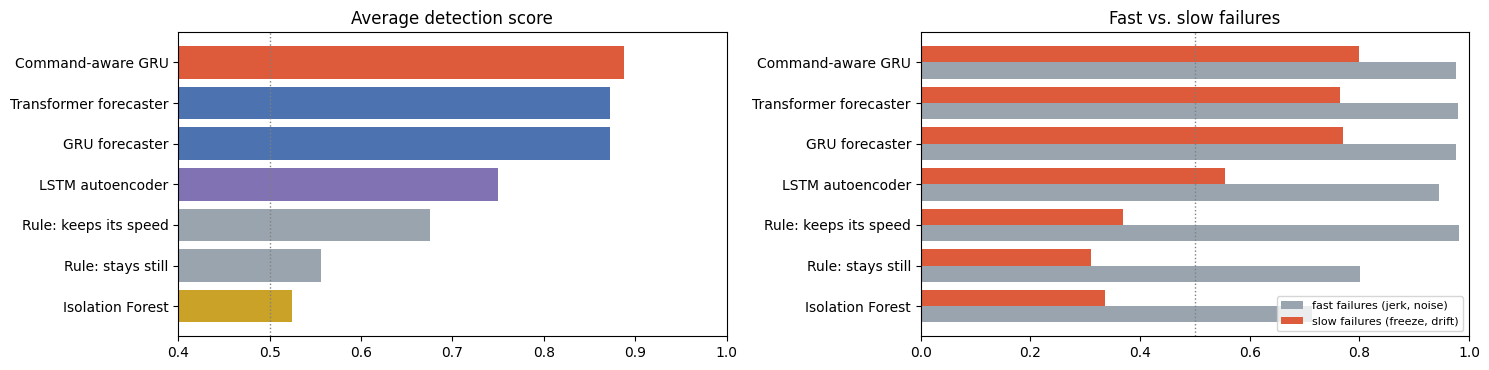


KEY RESULTS
 • RQ1: learned models predict the hand position 10 steps ahead with 16–18 mm error,
        vs 62–68 mm for the simple rules.
 • RQ2: fast failures are easy: the best simple rule already scores 0.98.
        slow failures need learning: best rule 0.37 vs best learned model 0.80.
        Isolation Forest (0.52) and the LSTM autoencoder (0.75) are clearly weaker.
 • RQ3: open. The commands in this dataset repeat the recorded movement, so the command idea cannot be tested.


In [9]:
if not HAVE_RESULTS:
    print("No saved results yet: run option1_motion_anomaly_detection.ipynb first.")
else:
    rq1 = pd.read_csv(os.path.join(RESULTS_DIR, "rq1_forecasting.csv"), index_col=0)
    summary = pd.read_csv(os.path.join(RESULTS_DIR, "summary_all_methods.csv"), index_col=0)

    print("RQ1 — How far off is the predicted hand position, 10 steps ahead?")
    col = [c for c in rq1.columns if "10 steps" in c][0]
    display(rq1[[col]].rename(columns={col: "error 10 steps ahead [mm]"}).sort_values("error 10 steps ahead [mm]").round(1))

    print("RQ2 — Detection score per failure type (1.0 = perfect, 0.5 = guessing):")
    table = summary[["average", "freeze", "drift", "jerk", "noise", "false alarms"]].sort_values("average", ascending=False)
    display(table.round(2))

    colors = {"rule": "#9aa4ae", "classic": "#c9a227", "rebuild": "#8172b3", "predict": "#4c72b0", "new idea": "#dd5a3a"}
    fig, axes = plt.subplots(1, 2, figsize=(15, 3.8))
    order = summary["average"].sort_values()
    axes[0].barh(order.index, order.values, color=[colors.get(summary.loc[n, "family"], "grey") for n in order.index])
    axes[0].axvline(0.5, color="grey", ls=":", lw=1)
    axes[0].set_xlim(0.4, 1.0); axes[0].set_title("Average detection score")
    x = np.arange(len(order))
    slow = summary.loc[order.index, ["freeze", "drift"]].mean(1)
    fast = summary.loc[order.index, ["jerk", "noise"]].mean(1)
    axes[1].barh(x - 0.2, fast, height=0.4, color="#9aa4ae", label="fast failures (jerk, noise)")
    axes[1].barh(x + 0.2, slow, height=0.4, color="#dd5a3a", label="slow failures (freeze, drift)")
    axes[1].set_yticks(x); axes[1].set_yticklabels(order.index); axes[1].set_xlim(0, 1.0)
    axes[1].axvline(0.5, color="grey", ls=":", lw=1); axes[1].legend(fontsize=8, loc="lower right")
    axes[1].set_title("Fast vs. slow failures")
    plt.tight_layout(); plt.show()

    rules = [n for n in summary.index if summary.loc[n, "family"] == "rule"]
    learned = [n for n in summary.index if summary.loc[n, "family"] in ("predict", "new idea")]
    best_rule_slow = summary.loc[rules, ["freeze", "drift"]].mean(1).max()
    best_learned_slow = summary.loc[learned, ["freeze", "drift"]].mean(1).max()
    best_rule_fast = summary.loc[rules, ["jerk", "noise"]].mean(1).max()
    print(f"""
KEY RESULTS
 • RQ1: learned models predict the hand position 10 steps ahead with {rq1.loc[learned, col].min():.0f}–{rq1.loc[learned, col].max():.0f} mm error,
        vs {rq1.loc[rules, col].min():.0f}–{rq1.loc[rules, col].max():.0f} mm for the simple rules.
 • RQ2: fast failures are easy: the best simple rule already scores {best_rule_fast:.2f}.
        slow failures need learning: best rule {best_rule_slow:.2f} vs best learned model {best_learned_slow:.2f}.
        Isolation Forest ({summary.loc['Isolation Forest', 'average']:.2f}) and the LSTM autoencoder ({summary.loc['LSTM autoencoder', 'average']:.2f}) are clearly weaker.
 • RQ3: open. The commands in this dataset repeat the recorded movement, so the command idea cannot be tested.""")

In [10]:
if HAVE_RESULTS:
    real = pd.read_csv(os.path.join(RESULTS_DIR, "real_recording_ranking.csv"))
    print("Most unusual REAL recordings (no failure added) — worth checking on video:")
    display(real.head(5)[["recording", "task", "peak score / threshold", "peak at step"]].round(1))

Most unusual REAL recordings (no failure added) — worth checking on video:


,recording,task,peak score / threshold,peak at step
0,293,stack red and yellow blocks,73.3,74
1,18,stack the cups,2.9,125
2,36,pick up the blue block and drop it in the box,2.4,59
3,205,pick and place the yellow block in the box,1.6,63
4,89,stack the blocks,1.4,10


## Step 15 — Limits and next steps

**Limits (honest list for the thesis):**
- The failures are **added artificially**; real failures may look different.
- The dataset has **no real failure labels** and **no independent commands**.
- The meaning of the 15 state numbers is **inferred** and should be confirmed with the dataset author.
- Results come from **one training run**; repeating with several random seeds is needed for fair conclusions.

**Next steps, in order:**
1. **Choose the new RQ3** (uncertainty-aware or task-phase-aware model) with your supervisor.
2. **Watch the most unusual real recordings** (Step 14, e.g. recording 293) and label what happened.
3. **Repeat all experiments with 3–5 seeds** and report averages.
4. **Write the thesis:** Part A of this notebook → *Data* chapter; Steps 9–13 → *Method*; Step 14 → *Results*; Step 15 → *Discussion*.

**Files in this project:**

| File | What it is |
|---|---|
| `dataset_review_and_project.ipynb` | this notebook: dataset review and project explanation |
| `option1_motion_anomaly_detection.ipynb` | all experiments (training, testing, comparison) |
| `processed/robot_motion.npz` | the robot numbers extracted from the dataset (4 MB) |
| `results/*.csv` | all result tables |